<a href="https://colab.research.google.com/github/astrajoan/CSCE-636/blob/main/Homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM

Load IMDB dataset and preprocess data

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 10000  # number of words to consider as features
maxlen = 500  # cut texts after this number of words (among top max_features most common words)
batch_size = 32

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences')

print('Pad sequences (samples x time)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

Loading data...
17465344/17464789 [==============================] - 0s 0us/step


<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


Build model and train

In [ ]:
from keras.layers import Embedding
from keras.layers import Dense
from keras.layers import LSTM
from keras.models import Sequential

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/10
157/157 [==============================] - 13s 33ms/step - loss: 0.5905 - acc: 0.6725 - val_loss: 0.3610 - val_acc: 0.8534
Epoch 2/10
157/157 [==============================] - 4s 28ms/step - loss: 0.3059 - acc: 0.8795 - val_loss: 0.3913 - val_acc: 0.8226
Epoch 3/10
157/157 [==============================] - 4s 29ms/step - loss: 0.2279 - acc: 0.9122 - val_loss: 0.2745 - val_acc: 0.8874
Epoch 4/10
157/157 [==============================] - 4s 28ms/step - loss: 0.1985 - acc: 0.9306 - val_loss: 0.3198 - val_acc: 0.8886
Epoch 5/10
157/157 [==============================] - 4s 27ms/step - loss: 0.1714 - acc: 0.9389 - val_loss: 0.2991 - val_acc: 0.8906
Epoch 6/10
157/157 [==============================] - 4s 28ms/step - loss: 0.1485 - acc: 0.9493 - val_loss: 0.3073 - val_acc: 0.8746
Epoch 7/10
157/157 [==============================] - 4s 28ms/step - loss: 0.1413 - acc: 0.9519 - val_loss: 0.3006 - val_acc: 0.8800
Epoch 8/10
157/157 [==============================] - 4s 28ms/step -

Plot learning curve

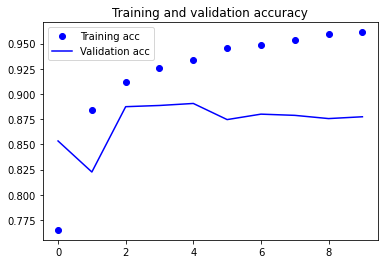

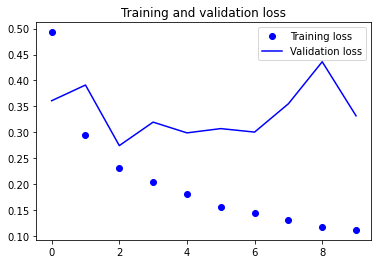

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Test on test set

In [ ]:
test_loss, test_acc = model.evaluate(input_test,y_test)
print("Test loss and accuracy: {} and {}".format(test_loss, test_acc))

782/782 [==============================] - 7s 9ms/step - loss: 0.3734 - acc: 0.8635
Test loss and accuracy: 0.373360276222229 and 0.8634799718856812


# Temperature forcasting

Gru layer


*   Load dataset and preprocess



In [1]:
!wget https://www.bgc-jena.mpg.de/wetter/mpi_roof_2020b.zip

--2021-02-11 19:25:30--  https://www.bgc-jena.mpg.de/wetter/mpi_roof_2020b.zip
Resolving www.bgc-jena.mpg.de (www.bgc-jena.mpg.de)... 195.37.229.23
Connecting to www.bgc-jena.mpg.de (www.bgc-jena.mpg.de)|195.37.229.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1298224 (1.2M) [application/zip]
Saving to: ‘mpi_roof_2020b.zip’

mpi_roof_2020b.zip  100%[===================>]   1.24M   605KB/s    in 2.1s    

2021-02-11 19:25:32 (605 KB/s) - ‘mpi_roof_2020b.zip’ saved [1298224/1298224]



In [2]:
!unzip /content/mpi_roof_2020b.zip

Archive:  /content/mpi_roof_2020b.zip
  inflating: mpi_roof_2020b.csv      


[Unicode error](https://stackoverflow.com/questions/22216076/unicodedecodeerror-utf8-codec-cant-decode-byte-0xa5-in-position-0-invalid-s)

[Bytes-like object required](https://stackoverflow.com/questions/33054527/typeerror-a-bytes-like-object-is-required-not-str-when-writing-to-a-file-in)

In [3]:
import os

# data_dir = '/home/ubuntu/data/'
# fname = os.path.join(data_dir, 'jena_climate_2009_2016.csv')
fname = '/content/mpi_roof_2020b.csv'

f = open(fname,'rb')
data = f.read()
f.close()

lines = data.split('\n'.encode())
header = lines[0].split(','.encode())
lines = lines[1:-1]

print(header)
print(len(lines))

import numpy as np

float_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(','.encode())[1:]]
    float_data[i, :] = values

mean = float_data[:200000].mean(axis=0)
float_data -= mean
std = float_data[:200000].std(axis=0)
float_data /= std

[b'"Date Time"', b'"p (mbar)"', b'"T (degC)"', b'"Tpot (K)"', b'"Tdew (degC)"', b'"rh (%)"', b'"VPmax (mbar)"', b'"VPact (mbar)"', b'"VPdef (mbar)"', b'"sh (g/kg)"', b'"H2OC (mmol/mol)"', b'"rho (g/m**3)"', b'"wv (m/s)"', b'"max. wv (m/s)"', b'"wd (deg)"', b'"rain (mm)"', b'"raining (s)"', b'"SWDR (W/m\xb2)"', b'"PAR (\xb5mol/m\xb2/s)"', b'"max. PAR (\xb5mol/m\xb2/s)"', b'"Tlog (degC)"', b'"CO2 (ppm)"\r']
26496


In [4]:
def generator(data, lookback, delay, min_index, max_index,
              shuffle=False, batch_size=128, step=6):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while 1:
        if shuffle:
            rows = np.random.randint(
                min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)

        samples = np.zeros((len(rows),
                           lookback // step,
                           data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices]
            targets[j] = data[rows[j] + delay][1]
        yield samples, targets

lookback = 1440
step = 6
delay = 144
batch_size = 128

train_gen = generator(float_data,
                      lookback=lookback,
                      delay=delay,
                      min_index=0,
                      max_index=10000,
                      shuffle=True,
                      step=step, 
                      batch_size=batch_size)
val_gen = generator(float_data,
                    lookback=lookback,
                    delay=delay,
                    min_index=10001,
                    max_index=20000,
                    step=step,
                    batch_size=batch_size)
test_gen = generator(float_data,
                     lookback=lookback,
                     delay=delay,
                     min_index=20001,
                     max_index=None,
                     step=step,
                     batch_size=batch_size)

# This is how many steps to draw from `val_gen`
# in order to see the whole validation set:
val_steps = (200000 - 100001 - lookback) // batch_size

# This is how many steps to draw from `test_gen`
# in order to see the whole test set:
test_steps = (len(float_data) - 200001 - lookback) // batch_size

Build model and train

In [ ]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32, input_shape=(None, float_data.shape[-1])))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit_generator(train_gen,
                              steps_per_epoch=500,
                              epochs=20,
                              validation_data=val_gen,
                              validation_steps=val_steps)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/20
500/500 [==============================] - 24s 33ms/step - loss: 0.3042 - val_loss: 0.3183
Epoch 2/20
500/500 [==============================] - 16s 32ms/step - loss: 0.2036 - val_loss: 0.3949
Epoch 3/20
500/500 [==============================] - 16s 32ms/step - loss: 0.1609 - val_loss: 0.4060
Epoch 4/20
500/500 [==============================] - 16s 31ms/step - loss: 0.1295 - val_loss: 0.4099
Epoch 5/20
500/500 [==============================] - 16s 32ms/step - loss: 0.1057 - val_loss: 0.4198
Epoch 6/20
500/500 [==============================] - 16s 32ms/step - loss: 0.0895 - val_loss: 0.4244
Epoch 7/20
500/500 [==============================] - 16s 32ms/step - loss: 0.0805 - val_loss: 0.4268
Epoch 8/20
500/500 [==============================] - 16s 32ms/step - loss: 0.0741 - val_loss: 0.4374
Epoch 9/20
500/500 [==============================] - 16s 31ms/step - loss: 0.0695 - val_loss: 0.4304
Epoch 10/20
500/500 [==============================] - 16s 33ms/step - loss: 0.066

Plot learning curve

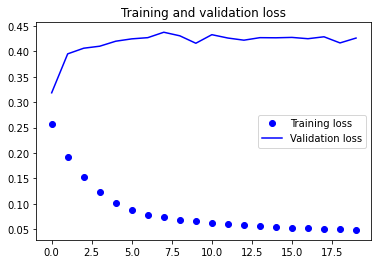

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Dropout

In [ ]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32,
                     dropout=0.2,
                     recurrent_dropout=0.2,
                     input_shape=(None, float_data.shape[-1])))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit_generator(train_gen,
                              steps_per_epoch=500,
                              epochs=40,
                              validation_data=val_gen,
                              validation_steps=val_steps)

Epoch 1/40


/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


500/500 [==============================] - 431s 859ms/step - loss: 0.3580 - val_loss: 0.3562
Epoch 2/40
500/500 [==============================] - 430s 860ms/step - loss: 0.2468 - val_loss: 0.3944
Epoch 3/40
500/500 [==============================] - 429s 859ms/step - loss: 0.2172 - val_loss: 0.4422
Epoch 4/40
500/500 [==============================] - 426s 852ms/step - loss: 0.1825 - val_loss: 0.4659
Epoch 5/40
500/500 [==============================] - 427s 854ms/step - loss: 0.1583 - val_loss: 0.4653
Epoch 6/40
500/500 [==============================] - 431s 861ms/step - loss: 0.1416 - val_loss: 0.4857
Epoch 7/40
500/500 [==============================] - 431s 862ms/step - loss: 0.1302 - val_loss: 0.4997
Epoch 8/40
500/500 [==============================] - 427s 854ms/step - loss: 0.1210 - val_loss: 0.4889
Epoch 9/40
500/500 [==============================] - 434s 867ms/step - loss: 0.1144 - val_loss: 0.4903
Epoch 10/40
500/500 [==============================] - 432s 864ms/step - lo

Plot learning curve

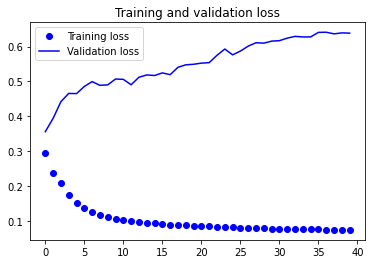

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Stack recurrent layers

In [6]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32,
                     dropout=0.1,
                     recurrent_dropout=0.5,
                     return_sequences=True,
                     input_shape=(None, float_data.shape[-1])))
model.add(layers.GRU(64, activation='relu',
                     dropout=0.1, 
                     recurrent_dropout=0.5))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit_generator(train_gen,
                              steps_per_epoch=500,
                              epochs=30,
                              validation_data=val_gen,
                              validation_steps=val_steps)

Epoch 1/30


/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


500/500 [==============================] - 739s 1s/step - loss: 0.3009 - val_loss: 0.3902
Epoch 2/30
500/500 [==============================] - 733s 1s/step - loss: 0.2088 - val_loss: 0.5098
Epoch 3/30
500/500 [==============================] - 743s 1s/step - loss: 0.1546 - val_loss: 0.5381
Epoch 4/30
500/500 [==============================] - 751s 2s/step - loss: 0.1289 - val_loss: 0.5518
Epoch 5/30
500/500 [==============================] - 758s 2s/step - loss: 0.1153 - val_loss: 0.6083
Epoch 6/30
500/500 [==============================] - 758s 2s/step - loss: 0.1054 - val_loss: 0.5947
Epoch 7/30
500/500 [==============================] - 745s 1s/step - loss: 0.1004 - val_loss: 0.6519
Epoch 8/30
500/500 [==============================] - 730s 1s/step - loss: 0.0947 - val_loss: 0.6856
Epoch 9/30
500/500 [==============================] - 735s 1s/step - loss: 0.0909 - val_loss: 0.6643
Epoch 10/30
500/500 [==============================] - 734s 1s/step - loss: 0.0882 - val_loss: 0.6758


Plot learning curve

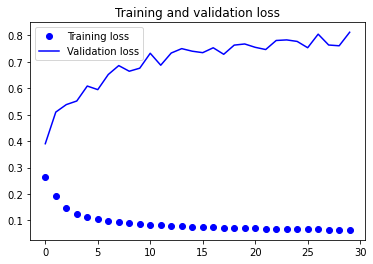

In [8]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# Bidirectional LSTM

Load IMDB dataset and preprocess data

In [ ]:
from keras.datasets import imdb
from keras.preprocessing import sequence
from keras import layers
from keras.models import Sequential

# Number of words to consider as features
max_features = 10000
# Cut texts after this number of words (among top max_features most common words)
maxlen = 500

# Load data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Reverse sequences
x_train = [x[::-1] for x in x_train]
x_test = [x[::-1] for x in x_test]

# Pad sequences
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

Build model and train

In [ ]:
from keras import backend as K
K.clear_session()

model = Sequential()
model.add(layers.Embedding(max_features, 32))
model.add(layers.Bidirectional(layers.LSTM(32)))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
157/157 [==============================] - 10s 49ms/step - loss: 0.6313 - acc: 0.6375 - val_loss: 0.4337 - val_acc: 0.8218
Epoch 2/10
157/157 [==============================] - 7s 45ms/step - loss: 0.3661 - acc: 0.8613 - val_loss: 0.3777 - val_acc: 0.8496
Epoch 3/10
157/157 [==============================] - 7s 44ms/step - loss: 0.2788 - acc: 0.8999 - val_loss: 0.3576 - val_acc: 0.8552
Epoch 4/10
157/157 [==============================] - 7s 45ms/step - loss: 0.2262 - acc: 0.9193 - val_loss: 0.3707 - val_acc: 0.8782
Epoch 5/10
157/157 [==============================] - 7s 45ms/step - loss: 0.2084 - acc: 0.9275 - val_loss: 0.3311 - val_acc: 0.8830
Epoch 6/10
157/157 [==============================] - 7s 47ms/step - loss: 0.1749 - acc: 0.9389 - val_loss: 0.3285 - val_acc: 0.8904
Epoch 7/10
157/157 [==============================] - 7s 46ms/step - loss: 0.1691 - acc: 0.9430 - val_loss: 0.3699 - val_acc: 0.8640
Epoch 8/10
157/157 [==============================] - 7s 46ms/step -